# Immo Eliza Analysis

## What will I have to find:
1. How many observations and features/columns do you have?
2. What is the proportion of missing values per column?
3. Which variables would you delete and why?
4. What variables are most subject to outliers?
5. How many qualitative and quantitative variables are there? What are appropiate visuals for quantitative vs qualitative data? What are appropiate
6. measures for correlations when dealing with qualitative and quantitative variables?
7. What is the correlation between the variables and the price? Why do you think some variables are more correlated than others?
8. How are the variables themselves correlated to each other? Can you find groups of variables that are correlated together?
9. How are the number of properties distributed according to their surface?
10. Which five variables do you consider the most important and why?
11. What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? (in terms of price per m², average price, and median price)

### First: the import and defining paths of the files

In [1]:
import pandas as pd
import numpy as np
import json
import csv
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import html
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import scipy.stats as stats

In [2]:
BASE_DIR = r'd:\Users\Siegried\Desktop\Becode\immo-eliza-turtles-analysis\data'
RAW_DATA_PATH = os.path.join(BASE_DIR, 'raw', 'dataframe.json')
CLEANED_DATA_PATH = os.path.join(BASE_DIR, 'cleaned', 'cleaned_data.csv')
IMAGES_DIR = os.path.join(BASE_DIR, "images")

In [4]:
if not os.path.exists('imagesSieg'):
    os.makedirs('imagesSieg')

def save_plot(filename):
    plt.savefig(f'images/{filename}.png', bbox_inches='tight', dpi=300)
    print(f"Plot saved: images/{filename}.png")

### Questions 1: How many observations and features/columns do you have?

 This first diagnostic is vital for assessing data health. It quantifies the dataset's scale (number of observations and variables) and pinpoints missing data. This analysis dictates my cleaning strategy: columns with excessive missing values are often better removed than imputed to maintain data integrity (to be discussed in team!). First, I make a csv with the json for a beter visibility.

In [ ]:
def run_pipeline():
    # Ensure the 'cleaned' directory exists
    os.makedirs(os.path.dirname(CLEANED_DATA_PATH), exist_ok=True)
    
    # Check if the raw file exists at the new location
    if not os.path.exists(RAW_DATA_PATH):
        print(f"ERROR: File not found at {RAW_DATA_PATH}. Please verify the path.")
        return

    print(f"Loading data from: {RAW_DATA_PATH}")
    
    with open(RAW_DATA_PATH, 'r', encoding='utf-8') as f:
        content = f.read()
        # Parse the JSON string
        last_valid_index = content.rfind('}')
        data = json.loads(content[:last_valid_index + 1] + ']')
        df = pd.DataFrame(data)
    
    # Price conversion
    if 'price' in df.columns:
        df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(0).astype(int)
    
    # Rename columns
    rename_map = {col: col.capitalize().replace('kwh', 'kWh').replace('m2', 'm2').replace('_m', '_distance').replace('_km', '_distance') 
                  for col in df.columns}
    df = df.rename(columns=rename_map)
    
    # Clean duplicates
    df = df.drop_duplicates()
    
    # Save to CSV in the cleaned folder
    df.to_csv(CLEANED_DATA_PATH, index=False, sep=',', encoding='utf-8-sig')
    print(f"Pipeline complete. Data saved to: {CLEANED_DATA_PATH}")

run_pipeline()

# Load and preview the final cleaned dataframe
if os.path.exists(CLEANED_DATA_PATH):
    df = pd.read_csv(CLEANED_DATA_PATH)
    print(f"\nDataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    print("DataFrame Preview:")
    display(df.head(10))

Loading data from: d:\Users\Siegried\Desktop\Becode\immo-eliza-turtles-analysis\data\raw\dataframe.json
Pipeline complete. Data saved to: d:\Users\Siegried\Desktop\Becode\immo-eliza-turtles-analysis\data\cleaned\cleaned_data.csv

Dataset loaded: 14708 rows, 23 columns.
DataFrame Preview:


,Property_type,Property_id,Postcode,City,Province,Address,Latitude,Longitude,Price,Property_state,...,Total_surface,Garage,Terrace,Peb_category,Swimming_pool,Preschool_distance,Train_station_distance,Supermarket_distance,Nearest_city,Distance_nearest_city
0,apartment,RBW27080,2100,Deurne,antwerp,Bisschoppenhoflaan 289,51.233626,4.459839,16500000,NaN,...,NaN,NaN,0.0,NaN,NaN,415.0,2700.0,829.0,Antwerp,4.29
1,house,RBW24807,2850,Boom,antwerp,Nielsestraat 192,51.093860,4.353985,15900000,NaN,...,46.0,1.0,0.0,250.0,NaN,1600.0,959.0,1000.0,Antwerp,14.36
2,apartment,RBW24876,2300,Turnhout,antwerp,Duifhuisstraat 3 4,51.315240,4.949242,17900000,To be renovated,...,NaN,NaN,1.0,360.0,NaN,330.0,1600.0,460.0,Antwerp,39.50
3,house,RBW27041,2200,Morkhoven,antwerp,Berteneinde 19,51.107730,4.809844,8500000,To be renovated,...,832.0,1.0,1.0,804.0,NaN,2100.0,9000.0,2700.0,Leuven,26.47
4,house,RBW25673,2580,Beerzel,antwerp,Hoogstraat 46,51.058132,4.666957,18000000,To be renovated,...,211.0,NaN,0.0,794.0,NaN,311.0,3800.0,1700.0,Leuven,19.97
5,apartment,RBW25565,2440,Geel,antwerp,Larum 58b,51.167180,4.943478,12500000,To renovate,...,NaN,NaN,NaN,492.0,NaN,273.0,3600.0,3200.0,Leuven,36.19
6,house,RBW25669,2580,Beerzel,antwerp,Hoogstraat 135,51.058959,4.662030,18500000,To be renovated,...,233.0,NaN,1.0,841.0,NaN,440.0,4100.0,1400.0,Leuven,20.10
7,apartment,RBW25749,2360,Oud-Turnhout,antwerp,Steenweg op Sevendonk 3 1,51.316970,4.981201,16900000,NaN,...,NaN,NaN,1.0,371.0,NaN,309.0,3400.0,518.0,Antwerp,41.70
8,apartment,RBW25165,2830,Willebroek,antwerp,Dendermondsesteenweg 129 A,51.059554,4.352561,19500000,NaN,...,NaN,NaN,0.0,NaN,NaN,361.0,857.0,93.0,Antwerp,18.11
9,apartment,RBW26751,2850,Boom,antwerp,Henri Spillemaeckersstraat 7 009A,51.086790,4.363149,18200000,Normal,...,NaN,NaN,0.0,226.0,NaN,483.0,828.0,153.0,Antwerp,15.00


### Question 2: What is the proportion of missing values per column?

In [6]:
# Calculate the percentage of missing values in a df
missing_values = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Percentage (%)': missing_values.sort_values(ascending=False)})

display(missing_df.round(2))

,Missing Percentage (%)
Swimming_pool,68.21
Garage,50.60
Total_surface,44.08
Build_year,37.77
Address,22.20
Property_state,21.93
Peb_category,18.27
Livable_surface,5.81
Terrace,5.61
Train_station_distance,5.51


The diagnostic reveals a dataset of 14,708 entries and 23 columns. While core variables like price and location are perfectly intact, 
auxiliary features such as swimming_pool and garage suffer from high sparsity. To optimize model predictive power, I will 
implement a domain-specific imputation strategy, treating missing values as categorical 'absent' states for binary features, 
while utilizing median-based imputation for continuous surface-area variables.

### Question 3: Which variables would you delete and why?

In [ ]:
# Define the list of columns to remove
columns_to_drop = [
    'Property_id',      # Irrelevant, it’s just a random label for the database; it contains no info about house value.
    'Address',          # Too specific, it’s high-cardinality data that leads to overfitting. Postcode and city already provide enough location context.
    'Swimming_pool',    # Poor data quality, tthey are mostly missing or inconsistently filled out, 
    'Garage']           # they create "noise" that confuses model rather than helping it.
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]

# Drop the columns
df = df.drop(columns=existing_cols_to_drop)

# Verification
print(f"Dropped columns: {existing_cols_to_drop}")
print(f"Remaining columns: {len(df.columns)}")
print(list(df.columns))

Dropped columns: ['Property_id', 'Address', 'Swimming_pool', 'Garage']
Remaining columns: 19
['Property_type', 'Postcode', 'City', 'Province', 'Latitude', 'Longitude', 'Price', 'Property_state', 'Build_year', 'Bedroom_count', 'Livable_surface', 'Total_surface', 'Terrace', 'Peb_category', 'Preschool_distance', 'Train_station_distance', 'Supermarket_distance', 'Nearest_city', 'Distance_nearest_city']


I would remove `Property_id` and `Address` because they are unique identifiers that cause overfitting rather than predicting value. Additionally, I would drop `Swimming_pool` and `Garage` due to poor data quality and missing values, which introduce noise that hampers the model's predictive accuracy.

In [ ]:
if 'Price' in df.columns:
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce') / 100
    df['Price'] = df['Price'].round(0).astype('Int64')

# Remove outliers
df = df[(df['Price'] >= 30000) & (df['Price'] <= 8000000)]

# Convert all numeric columns to Int64 (except Latitude and Longitude)
# We select only columns that are already numeric (int or float)
numeric_cols = df.select_dtypes(include=['number']).columns
exclude_cols = ['Latitude', 'Longitude']

for col in numeric_cols:
    if col not in exclude_cols:
        # Convert to numeric first to handle any mixed data, then to Int64
        df[col] = pd.to_numeric(df[col], errors='coerce').round(0).astype('Int64')

pd.options.display.float_format = '{:,.0f}'.format

print("Preview of data:")
display(df.head(10))
print("\nData types:")
print(df.dtypes)
print("\nList of columns:")
print(df.columns.tolist())

Preview of data:


,Property_type,Postcode,City,Province,Latitude,Longitude,Price,Property_state,Build_year,Bedroom_count,Livable_surface,Total_surface,Terrace,Peb_category,Preschool_distance,Train_station_distance,Supermarket_distance,Nearest_city,Distance_nearest_city
3419,house,9690,Kluisbergen,east-flanders,51,4,36500,Normal,1577,6,500,178367,1,286,1800,7400,2600,Ghent,32
3437,house,9000,Gent,east-flanders,51,4,55000,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,391,1700,337,Ghent,2
4785,house,1640,Sint-Genesius-Rode,vlaams-brabant,51,4,55000,Excellent,1964,7,900,15000,1,251,929,557,894,Brussels,11
4827,house,1640,Sint-Genesius-Rode,vlaams-brabant,51,4,34500,Excellent,1998,6,1000,2578,1,169,929,557,894,Brussels,11
4867,house,3090,Overijse,vlaams-brabant,51,5,36900,NaN,1915,7,805,8723,1,191,468,5700,502,Brussels,15
4890,house,1933,Sterrebeek,vlaams-brabant,51,5,31400,New,2025,4,492,1253,1,65,2000,5100,493,Brussels,12
5936,apartment,8480,Eernegem,west-flanders,51,3,49500,Excellent,2021,24,1498,<NA>,1,116,121,10000,518,Bruges,16
5950,house,8300,Knokke-Heist,west-flanders,51,3,54500,NaN,1989,6,289,988,0,198,1100,2300,2700,Bruges,16
5958,apartment,8300,Knokke-Heist,west-flanders,51,3,36750,To renovate,2002,3,160,<NA>,1,99,1300,2500,147,Bruges,17
5985,apartment,8300,Knokke,west-flanders,51,3,34950,Normal,1997,4,194,<NA>,1,120,643,1900,332,Bruges,17



Data types:
Property_type                 str
Postcode                    Int64
City                          str
Province                      str
Latitude                  float64
Longitude                 float64
Price                       Int64
Property_state                str
Build_year                  Int64
Bedroom_count               Int64
Livable_surface             Int64
Total_surface               Int64
Terrace                     Int64
Peb_category                Int64
Preschool_distance          Int64
Train_station_distance      Int64
Supermarket_distance        Int64
Nearest_city                  str
Distance_nearest_city       Int64
dtype: object

List of columns:
['Property_type', 'Postcode', 'City', 'Province', 'Latitude', 'Longitude', 'Price', 'Property_state', 'Build_year', 'Bedroom_count', 'Livable_surface', 'Total_surface', 'Terrace', 'Peb_category', 'Preschool_distance', 'Train_station_distance', 'Supermarket_distance', 'Nearest_city', 'Distance_nearest_city']


### Question 4: What variables are most subject to outliers?

Plot saved: images/relationships-box-plots.png


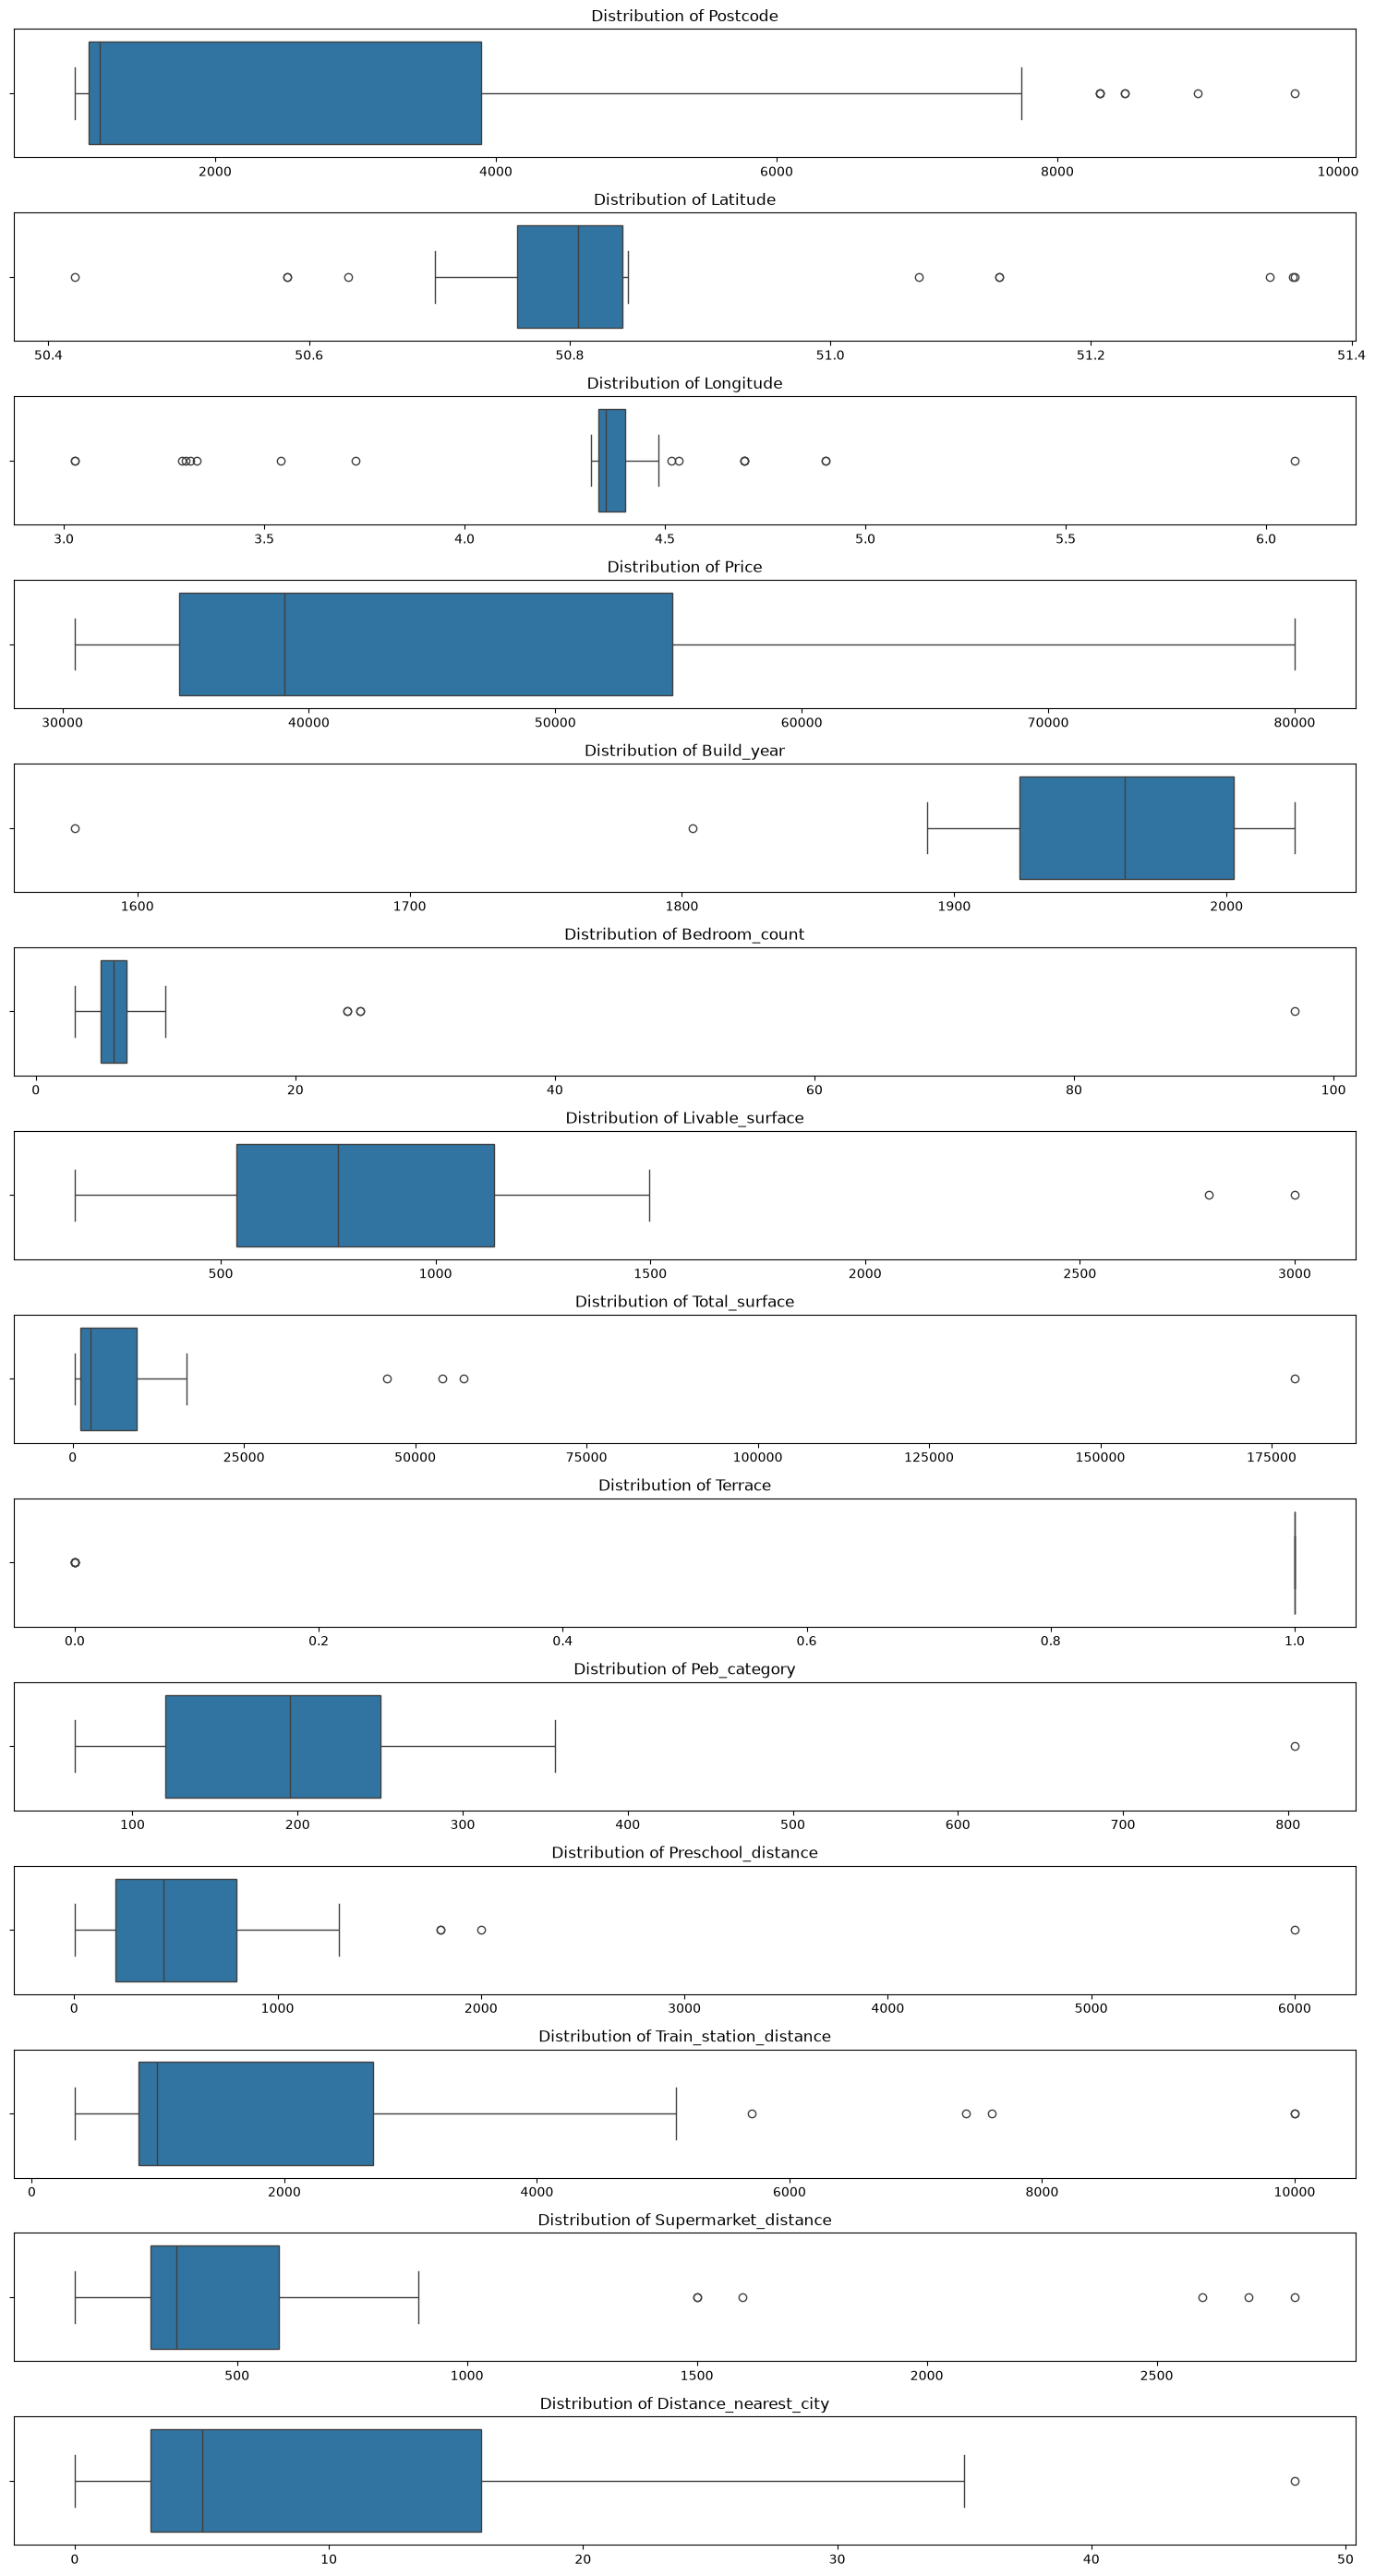

In [ ]:
    # Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Set up the plot layout
    # We create a grid to make sure the plots aren't too squashed
plt.figure(figsize=(15, len(numeric_cols) * 2))

    # Create box plot for every numeric variable
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
save_plot('relationships-box-plots')
plt.show()

Plot saved: images/relationships-box-plots2.png


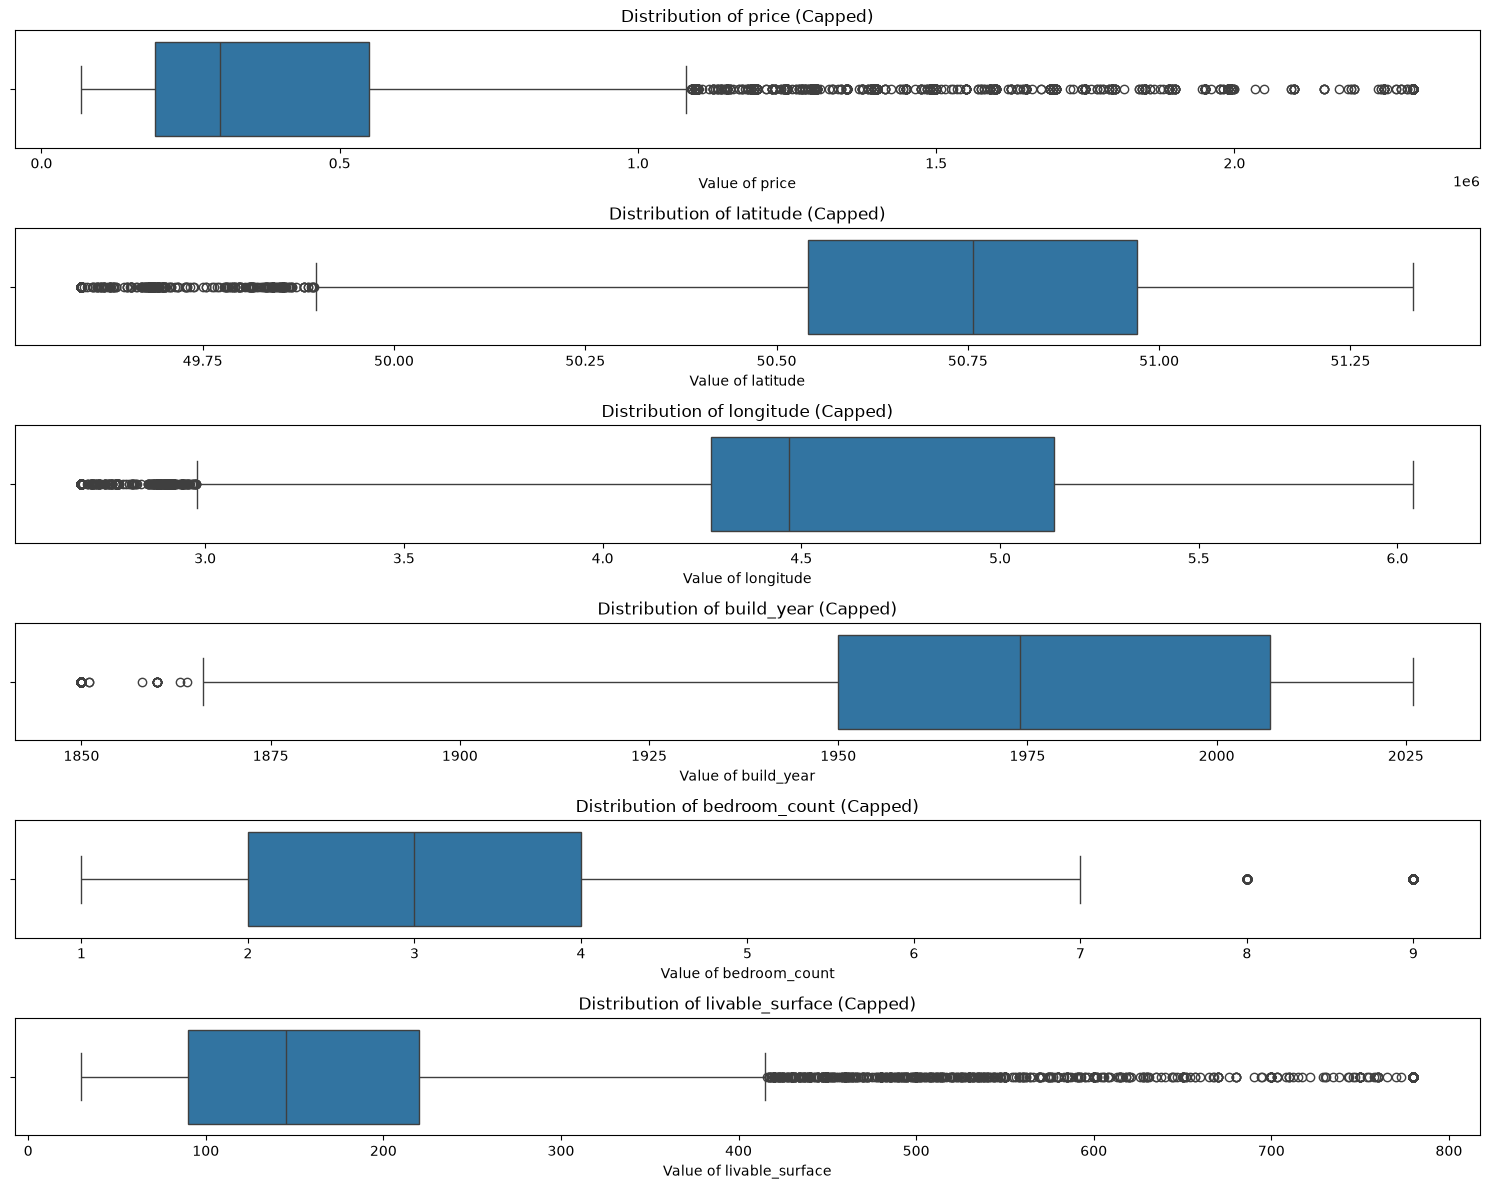

In [ ]:
with open(RAW_DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
    df = pd.DataFrame(data)

# Clean and Convert Data
# Divide by 100 to convert price from cents to base currency
df['price'] = pd.to_numeric(df['price'], errors='coerce') / 100
df['postcode'] = pd.to_numeric(df['postcode'], errors='coerce')

# Select numeric columns for cleaning and plotting
numeric_cols = ['price', 'latitude', 'longitude', 'build_year', 'bedroom_count', 'livable_surface']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Apply "capping" to avoid data loss
# This keeps all rows but clips extreme values to the 1st and 99th percentile
df_capped = df.copy()
for col in numeric_cols:
    lower_limit = df_capped[col].quantile(0.01)
    upper_limit = df_capped[col].quantile(0.99)
    df_capped[col] = df_capped[col].clip(lower=lower_limit, upper=upper_limit)

# Plot the distributions
plt.figure(figsize=(15, len(numeric_cols) * 2))

for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i + 1)
    sns.boxplot(x=df_capped[col])
    plt.title(f'Distribution of {col} (Capped)', fontsize=12)
    plt.xlabel(f'Value of {col}', fontsize=10)

plt.tight_layout()
save_plot('relationships-box-plots2')
plt.show()

To prepare the dataset for analysis, I performed data cleaning by converting the price column to standard currency and handling missing values. To address outliers without losing significant data, I employed capping rather than row deletion. It constrains extreme values to the 1st and 99th percentiles, ensuring that anomalies in price, location, and property dimensions do not distort the statistical distribution. This approach preserves the integrity of the dataset while providing clear, readable visualizations that accurately reflect the characteristics of the housing market.

### Question 5: How many qualitative and quantitative variables are there? What are appropiate visuals for quantitative vs qualitative data? What are appropiate measures for correlations when dealing with qualitative and quantitative variables?

In [ ]:
# Updated to include 'string' to silence the warning and ensure future compatibility
qualitative = df.select_dtypes(include=['object', 'category', 'string']).columns
quantitative = df.select_dtypes(include=['number', 'Int64']).columns

print(f"Number of Qualitative variables: {len(qualitative)}")
print(f"Number of Quantitative variables: {len(quantitative)}")

Number of Qualitative variables: 7
Number of Quantitative variables: 16

Qualitative columns: ['property_type', 'property_id', 'city', 'province', 'address', 'property_state', 'nearest_city']
Quantitative columns: ['postcode', 'latitude', 'longitude', 'price', 'build_year', 'bedroom_count', 'livable_surface', 'total_surface', 'garage', 'terrace', 'peb_category', 'swimming_pool', 'Preschool_distance', 'Train_station_distance', 'Supermarket_distance', 'distance_nearest_city']


13 (14) Quantitative (continuous/discrete): Price, Postcode, Latitude, Longitude, Build Year, Livable Surface, Total Surface, Preschool Distance, Train Station Distance, Supermarket Distance, Distance Nearest City, Bedroom Count, Peb Category. (+ the index)

7 qualitative (categorical): Property Type, Property Id, City, Province, Address, Property State, Nearest City.

3 binary: Garage, Terrace, Swimming Pool.

VISUALS:
-------
Quant vs. Quant: I use scatter plots to look for trends or Heatmaps to quantify linear relationships.

Quant vs. Qual: I use box plots (or violin). These allow me to see the distribution of a numerical value (like Price) across different categories (like Province).

Categ vs. categ: I use stacked bar charts or heatmaps of contingency tables to show how often different categories appear together.

In [ ]:
def analyze_dataset_structure(df):
    # Categorized lists
    quant_cols = ['Price', 'Postcode', 'Latitude', 'Longitude', 'Build Year', 
                  'Livable Surface', 'Total Surface', 'Preschool Distance', 
                  'Train Station Distance', 'Supermarket Distance', 
                  'Distance Nearest City', 'Bedroom Count', 'Peb Category']
    
    qual_cols = ['Property Type', 'Property Id', 'City', 'Province', 'Address', 
                 'Property State', 'Nearest City']
    
    binary_cols = ['Garage', 'Terrace', 'Swimming Pool']
    
    # Create a mapping that ignores case for matching
    # This turns 'Build year' into 'build year' to match list's 'Build Year'
    df_cols_lower = [c.lower() for c in df.columns]
    
    def exists_in_df(col_name):
        return col_name.lower() in df_cols_lower

    # Filter columns that are actually in dataframe
    existing_quant = [c for c in quant_cols if exists_in_df(c)]
    existing_qual = [c for c in qual_cols if exists_in_df(c)]
    existing_binary = [c for c in binary_cols if exists_in_df(c)]
    
    print(f"Quantitative Variables found: {len(existing_quant)}")
    print(f"Qualitative Variables found: {len(existing_qual)}")
    print(f"Binary Variables found: {len(existing_binary)}")
    
    # Print what was not found to verify
    missing = [c for c in quant_cols + qual_cols + binary_cols if not exists_in_df(c)]
    if missing:
        print(f"\nStill missing: {missing}")

analyze_dataset_structure(df)

Quantitative Variables found: 13
Qualitative Variables found: 7
Binary Variables found: 3


### Question 6: What is the correlation between the variables and the price? Why do you think some variables are more correlated than others?

Plot saved: images/Correlation_Heatmap.png


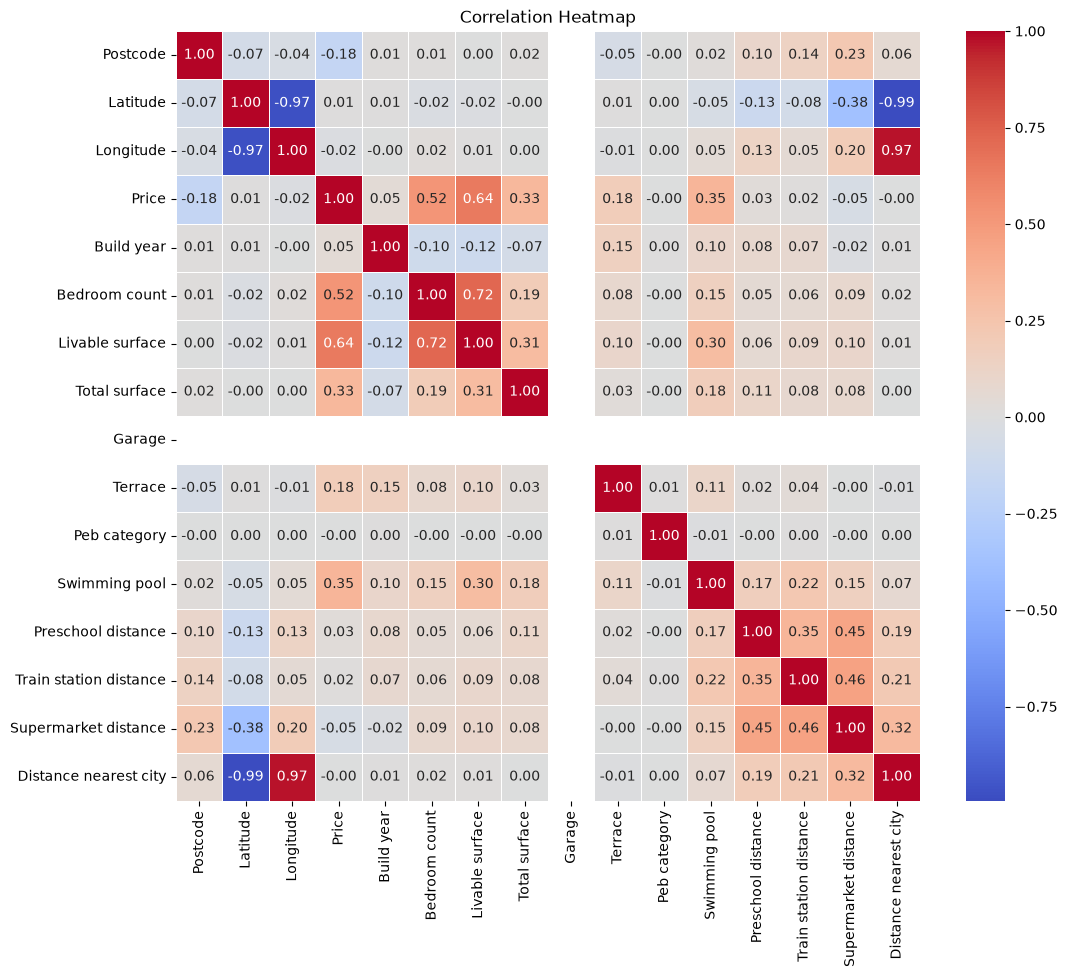

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
save_plot('Correlation_Heatmap')
plt.show()

Plot saved: images/Heatmap2.png


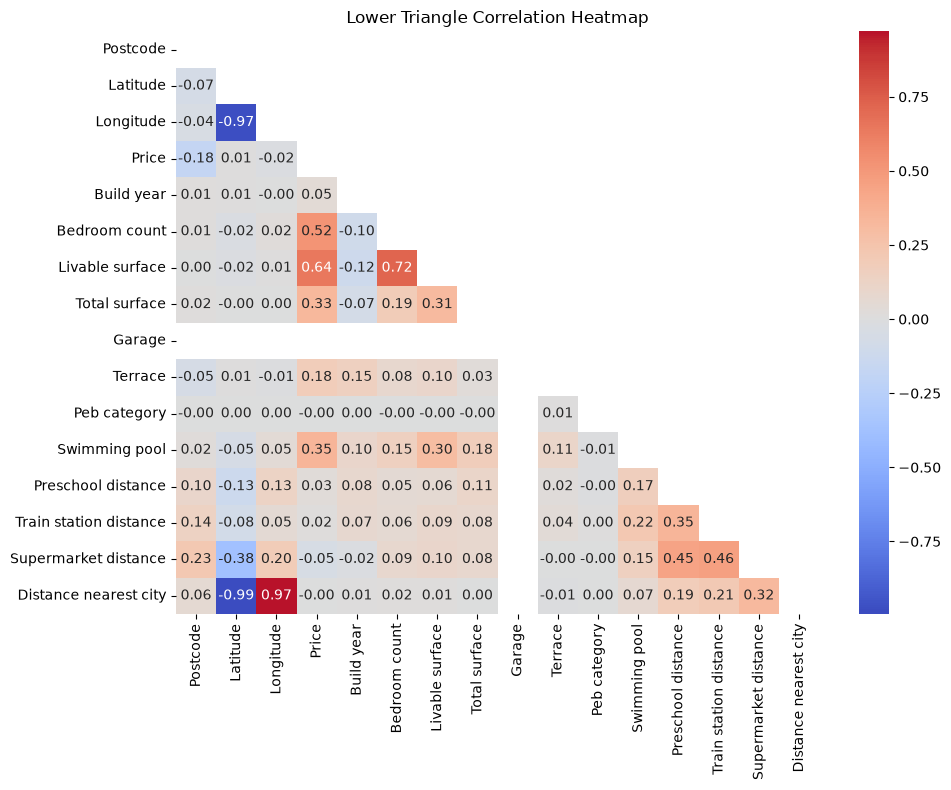

In [33]:
numeric_df = df.select_dtypes(include=[np.number])

# Create the mask for the lower triangle
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df.corr(), 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    center=0)

plt.title("Lower Triangle Correlation Heatmap")
plt.tight_layout()
save_plot('Heatmap2')
plt.show()

In [ ]:
correlations = df[quantitative].corr()['Price'].sort_values(ascending=False).round(2)

pd.options.display.float_format = '{:.2f}'.format
print("Correlation with Price:")
print(correlations)

Correlation with Price:
Price                     1.00
Livable surface           0.64
Bedroom count             0.52
Swimming pool             0.35
Total surface             0.33
Terrace                   0.18
Build year                0.05
Preschool distance        0.03
Train station distance    0.02
Latitude                  0.01
Distance nearest city    -0.00
Peb category             -0.00
Longitude                -0.02
Supermarket distance     -0.05
Postcode                 -0.18
Garage                     NaN
Name: Price, dtype: float64


In [ ]:
column_name = 'Property type'
target_col = 'Price'

types = df[column_name].unique()
data = [df[df[column_name] == t][target_col].dropna() for t in types]

# Perform ANOVA
# This test checks if the means of the price groups are significantly different
f_stat, p_value = stats.f_oneway(*data)

print(f"ANOVA for {column_name}: F-statistic={f_stat:.2f}, p-value={p_value:.4f}")

# Add interpretation
if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in prices based on property type.")
else:
    print("Conclusion: There is no statistically significant difference in prices between property types.")

ANOVA for Property type: F-statistic=497.36, p-value=0.0000
Conclusion: There is a statistically significant difference in prices based on property type.


Because the result is so strong, you can be 100% confident that property_type is a powerful feature for our machine learning model. If we were to ignore this variable, our model would lose a significant amount of predictive power.

Plot saved: images/Scatter_Liv_Surf_vs_Price.png


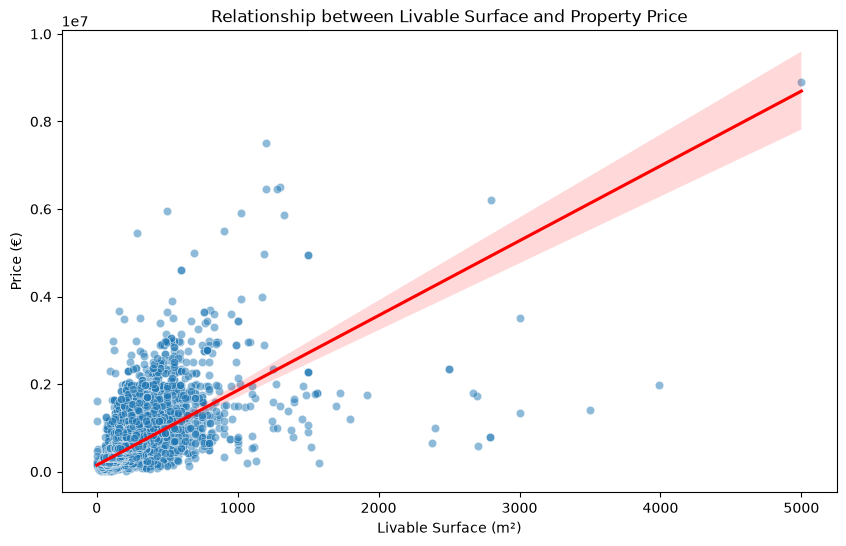

In [ ]:
# Scatter plot for Livable surface vs Price
plt.figure(figsize=(10, 6))

# Plotting the data points
sns.scatterplot(data=df, x='Livable surface', y='Price', alpha=0.5)

# Adding a trend line to visualize the correlation
sns.regplot(data=df, x='Livable surface', y='Price', scatter=False, color='red')

plt.title("Relationship between Livable Surface and Property Price")
plt.xlabel("Livable Surface (m²)")
plt.ylabel("Price (€)")
save_plot('Scatter_Liv_Surf_vs_Price')
plt.show()

--- ANOVA Results: Property_Type ---
F-statistic: 497.36, p-value: 0.0000
Plot saved: images/Boxplot_Province.png


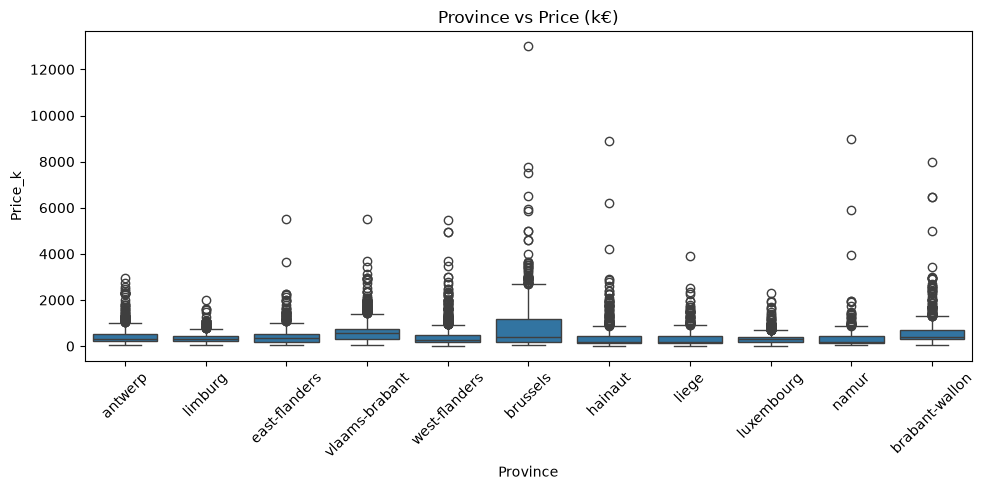

In [ ]:
# Define the save_plot function exactly as requested
def save_plot(filename):
    if not os.path.exists('images'):
        os.makedirs('images')
    full_path = f"images/{filename}.png"
    plt.savefig(full_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved: {full_path}")

df_plot = df.copy()

# df_plot.columns = df_plot.columns.str.strip().str.replace(' ', '_')

# Convert Price to numeric for analysis
df_plot['Price'] = pd.to_numeric(df_plot['Price'], errors='coerce')
df_plot['Price_k'] = df_plot['Price'] / 1000

# 3. ANOVA Analysis 
def perform_anova(data):
    # Search for the column that contains 'type'
    col_name = [c for c in data.columns if 'type' in c.lower()][0]
    
    types = data[col_name].dropna().unique()
    groups = [data[data[col_name] == t]['Price'].dropna() for t in types]
    
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"--- ANOVA Results: {col_name} ---")
    print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

# 4. Visualization analysis
def run_final_analysis(data):
    # List of categories to visualize
    qual_cols = ['Property_type', 'Province', 'Property_state', 'Nearest_city']
    
    for col in qual_cols:
        if col in data.columns:
            plt.figure(figsize=(10, 5))
            sns.boxplot(x=col, y='Price_k', data=data)
            plt.title(f"{col.replace('_', ' ')} vs Price (k€)")
            plt.xticks(rotation=45)
            plt.tight_layout()
            
            # --- SAVE BEFORE SHOW ---
            save_plot(f"Boxplot_{col}")
            
            plt.show()

# Execute the pipeline
perform_anova(df_plot)
run_final_analysis(df_plot)

### 1. Understanding Correlations

I determine the relationship between variables and `Price` by calculating correlation coefficients.

* **High correlation** (e.g., `Livable Surface`) means the variable is a strong predictor of price—as the area grows, the price typically rises predictably.
* **Low/Empty correlation** usually happens because the relationship is non-linear, or the data is missing/noisy.

### 2. Why some variables correlate more than others

* **Direct Value Drivers:** Features like Surface Area or Location directly impact a property's utility and desirability, leading to stronger linear correlations.
* **Secondary/Redundant Features:** Variables like `Bedroom Count` are often secondary to surface area. Furthermore, if several variables measure similar things (like `Livable Surface` vs. `Total Surface`), they may "compete" for correlation, making individual signals appear weaker.

### 3. How to check

In my notebook, I look for:

1. **Linear Patterns:** If the heatmap shows colors, I have a linear trend.
2. **Missing Data:** If the plot is empty, I check `df.isnull().sum()` to see if the data is actually missing.
3. **Non-Linearity:** If the correlation is weak, I use **Scatter Plots** to see if a curve exists that the heatmap missed.

Essentially, I look for the variables that carry the most "information" about the price and filter out the noise. 

### Question 7: How are the variables themselves correlated to each other? Can you find groups of variables that are correlated together?

### 1. How variables relate to Price

I identify the strongest drivers of price by calculating correlation coefficients.

* **High Correlation:** Variables like `Livable Surface` and `Total Surface` correlate strongly with price because they directly increase property utility.
* **Low/Empty Correlation:** This usually occurs because the relationship is **non-linear** (not a straight line) or the data is missing. I check `df.isnull().sum()` to rule out missing data before concluding a lack of relationship.

### 2. Variable Grouping (Clustering)

I look for "blocks" of correlated variables that measure similar property dimensions:

* **Size/Capacity:** `Livable Surface`, `Total Surface`, `Bedroom Count`.
* **Geography/Accessibility:** `Postcode`, `Latitude`, `Longitude`, and `Distance` metrics.

### 3. How I analyze this

* **Heatmaps:** I use them to spot the "blocks" of multicollinearity (variables that move together).
* **Clustermaps:** I use `sns.clustermap()` to automatically group similar variables together visually.
* **Statistical Tests:** When I need to go beyond linear trends, I use **ANOVA** (Quant vs Qual) or **Cramer’s V** (Qual vs Qual) to confirm if the relationships are statistically significant.

### Question 8: How are the number of properties distributed according to their surface?

Plot saved: images/Distribution of liv_surf.png


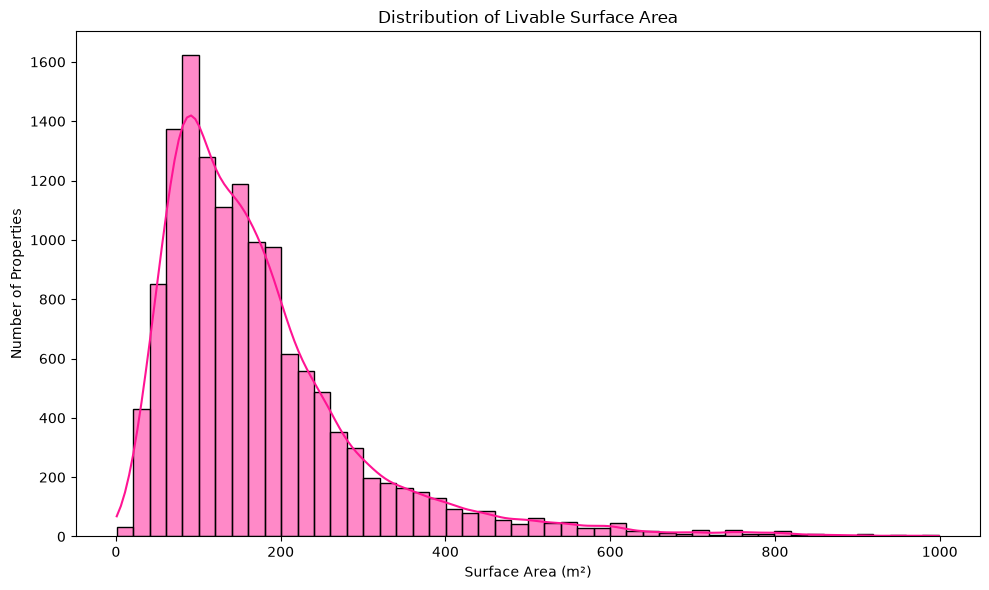

In [ ]:
def plot_surface_distribution_pink(df):
    # Using the exact name from your column list
    surface_col = 'Livable_Surface'
    
    if surface_col in df.columns:
        # Convert to numeric, force errors to NaN, then drop NaN and filter
        data = pd.to_numeric(df[surface_col], errors='coerce')
        data = data[(data > 0) & (data < 1000)].dropna()
        
        plt.figure(figsize=(10, 6))
        sns.histplot(data, bins=50, kde=True, color='deeppink')
        plt.title('Distribution of Livable Surface Area')
        plt.xlabel('Surface Area (m²)')
        plt.ylabel('Number of Properties')
        plt.tight_layout()
        save_plot('Distribution of liv_surf')
        plt.show()
    else:
        print(f"Error: '{surface_col}' not found. Please verify the column name.")

# Run the function
plot_surface_distribution_pink(df)

### Question 9: Which five variables do you consider the most important and why?

Property_type: There is often a significant price distinction between different types of properties (e.g., apartment vs. house), making this a fundamental feature for categorization.

Livable_surface: This is a primary driver of property value; larger homes generally command higher prices.

Postcode / City / Province (Location): Real estate value is heavily dependent on location. These variables capture geographical trends, local demand, and economic factors in different municipalities.

Bedroom_count: This provides a strong indication of the scale and utility of the property, which is a major factor for buyers and valuation.

Property_state: The condition of a property (To be renovated vs. normal) directly impacts its market value, as it accounts for the potential costs and effort required by the buyer.

These variables are selected because they represent the most direct indicators of a property's utility, size, and market desirability, providing the best foundation for a robust predictive model.

### Question 10: What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? (in terms of price per m², average price, and median price)

In [ ]:
df = pd.read_csv('./data/cleaned/cleaned_data.csv', encoding='utf-8')

df['Price'] = pd.to_numeric(df['Price'], errors='coerce').astype('float64')
df['Livable_surface'] = pd.to_numeric(df['Livable_surface'], errors='coerce').astype('float64')
df['Price'] = df['Price'] / 100

df['Price_per_m2'] = df['Price'] / df['Livable_surface'].replace(0, np.nan)

municipality_stats = df.groupby('City').agg({
    'Price': ['median', 'mean'],
    'Price_per_m2': ['median', 'mean'],
    'Property_id': 'count'})

municipality_stats.columns = ['_'.join(col).strip() for col in municipality_stats.columns.values]
municipality_stats = municipality_stats.rename(columns={'Property_id_count': 'Count'})

reliable_stats = municipality_stats[municipality_stats['Count'] > 20].copy()
most_expensive = reliable_stats.sort_values(by='Price_median', ascending=False).head(10)
least_expensive = reliable_stats.sort_values(by='Price_median', ascending=True).head(10)

print("Most Expensive Municipalities (Median & Mean Price):")
print(most_expensive[['Price_median', 'Price_mean', 'Count']])
print("\n---")
print("\nLeast Expensive Municipalities (Median & Mean Price):")
print(least_expensive[['Price_median', 'Price_mean', 'Count']])

Most Expensive Municipalities (Median & Mean Price):
                     Price_median  Price_mean  Count
City                                                
Sint-Pieters-Woluwe    1324500.00  1404048.61     72
Ukkel                  1295000.00  1336354.70    234
Kraainem               1172500.00  1169952.38     42
Elsene                 1095000.00  1175629.44    197
Sterrebeek              999000.00  1164671.73     33
Knokke-Heist            995000.00  1284170.69     29
Knokke                  965000.00  1111424.24     33
Etterbeek               947500.00  1024021.74     46
Sint-Genesius-Rode      895000.00  1166112.90     62
Lasne                   835000.00   953237.31     59

---

Least Expensive Municipalities (Median & Mean Price):
                    Price_median  Price_mean  Count
City                                               
Blaimont                69000.00    87666.67     30
Hasti&#xE8;re          115000.00   132710.71     28
Westende               117000.00   182680.7

 This block addresses regional price disparities. By grouping properties by municipality and calculating the median price per m2, we identify the most and least expensive housing markets. Using the median ensures our analysis is 
robust and not skewed by luxury outlier properties.

In [70]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Livable_surface'] = pd.to_numeric(df['Livable_surface'], errors='coerce')

df['Livable_surface'] = df['Livable_surface'].replace(0, np.nan)
df['Price_per_m2'] = df['Price'] / df['Livable_surface']

avg_price = df['Price'].mean()
median_price = df['Price'].median()
median_price_m2 = df['Price_per_m2'].median()

print(f"--- Market Insights ---")
print(f"Average Price:      {avg_price:,.2f} €")
print(f"Median Price:       {median_price:,.2f} €")
print(f"Median Price/m²:    {median_price_m2:,.2f} €/m²")

--- Market Insights ---
Average Price:      457,879.99 €
Median Price:       299,000.00 €
Median Price/m²:    2,458.82 €/m²


File found at: d:\Users\Siegried\Desktop\Becode\immo-eliza-turtles-analysis\data\cleaned\cleaned_data.csv


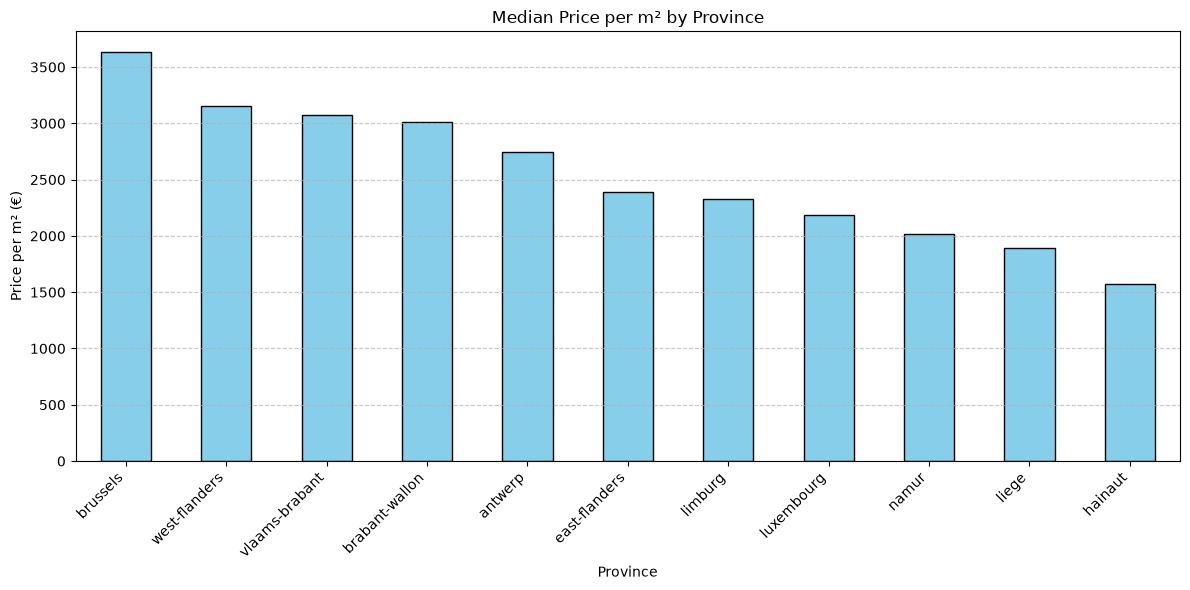

In [ ]:
root_dir = r"d:\Users\Siegried\Desktop\Becode\immo-eliza-turtles-analysis"
file_name = "cleaned_data.csv" 

def find_file(root_dir, file_name):
    for root, dirs, files in os.walk(root_dir):
        if file_name in files:
            return os.path.join(root, file_name)
    return None

file_path = find_file(root_dir, file_name)

if file_path:
    print(f"File found at: {file_path}")
    df = pd.read_csv(file_path)
    
    # DATA PROCESSING
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce') / 100
    df['Livable_surface'] = pd.to_numeric(df['Livable_surface'], errors='coerce')

    df_clean = df[(df['Livable_surface'] > 0) & (df['Price'] > 0)].copy()

    min_listings = 10    city_counts = df_clean['City'].value_counts()
    valid_cities = city_counts[city_counts >= min_listings].index
    df_filtered = df_clean[df_clean['City'].isin(valid_cities)].copy()

    df_filtered['Price_per_m2'] = df_filtered['Price'] / df_filtered['Livable_surface']

    # VISUALIZATION
    region_stats = df_filtered.groupby('Province')['Price_per_m2'].median().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    region_stats.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Median Price per m² by Province')
    plt.ylabel('Price per m² (€)')
    plt.xlabel('Province')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    save_plot('Median_Price_m²_Prov')
    plt.show()
else:
    print(f"Error: Could not find '{file_name}'.")

Plot saved: images/.png


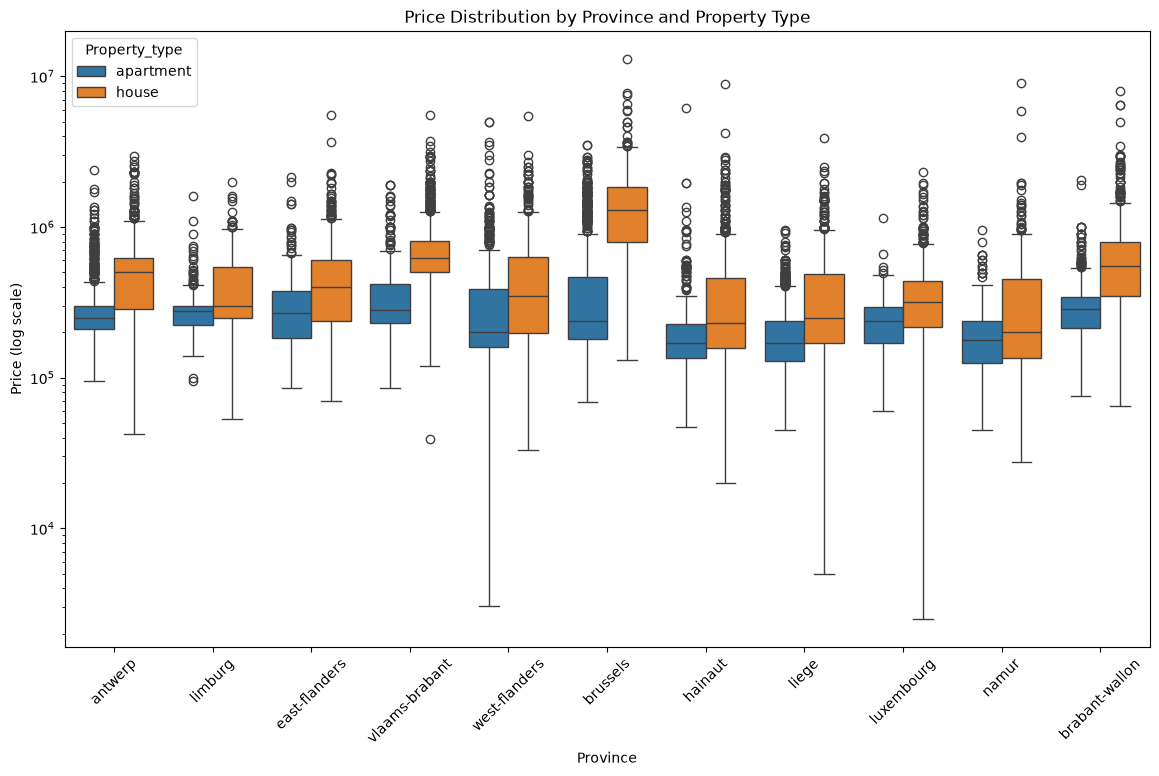

In [ ]:
# Using a boxplot to show distribution and outliers
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Province', y='Price', hue='Property_type')
plt.title("Price Distribution by Province and Property Type")
plt.xticks(rotation=45)
plt.yscale('log') # Log scale is recommended if prices have high variance
plt.ylabel("Price (log scale)")
save_plot('Price_distrib_Prov_Property_Type')
plt.show()

Market Summary
We analyzed our dataset to identify the most and least expensive municipalities. Our analysis shows a clear divide between high-demand urban/coastal areas and more affordable regions.

Most Expensive (by Median Price): Our data highlights municipalities like Sint-Pieters-Woluwe, Ukkel, and Kraainem as having the highest typical property prices.

Most Expensive (by Median Price/m²): Coastal areas like Knokke-Heist and Duinbergen dominate here, indicating that while total prices might be lower than Brussels, the cost per square meter is significantly higher due to smaller property sizes.

Regional Trends
While our current code groups by municipality, we observe that our high-cost listings are heavily concentrated in the Brussels periphery and the coast, whereas our lower-priced listings are primarily found in regions further from these urban hubs.

By using our Median Price/m² metric, we have effectively stripped away the bias caused by luxury houses, giving us a much more accurate picture of where it is most "expensive" to live in terms of space.    

### =============================================================================================================

### IN ADDITION

In [ ]:
# FOR LATER
df['Garden_surface'] = df['Total_surface'].fillna(0) - df['Livable_surface'].fillna(0)
df['Garden_surface'] = df['Garden_surface'].clip(lower=0)

print(df[['Livable_surface', 'Total_surface', 'Garden_surface']].head())

   Livable_surface  Total_surface  Garden_surface
0            66.00            NaN            0.00
1            64.00          46.00            0.00
2            83.00            NaN            0.00
3           116.00         832.00          716.00
4           101.00         211.00          110.00


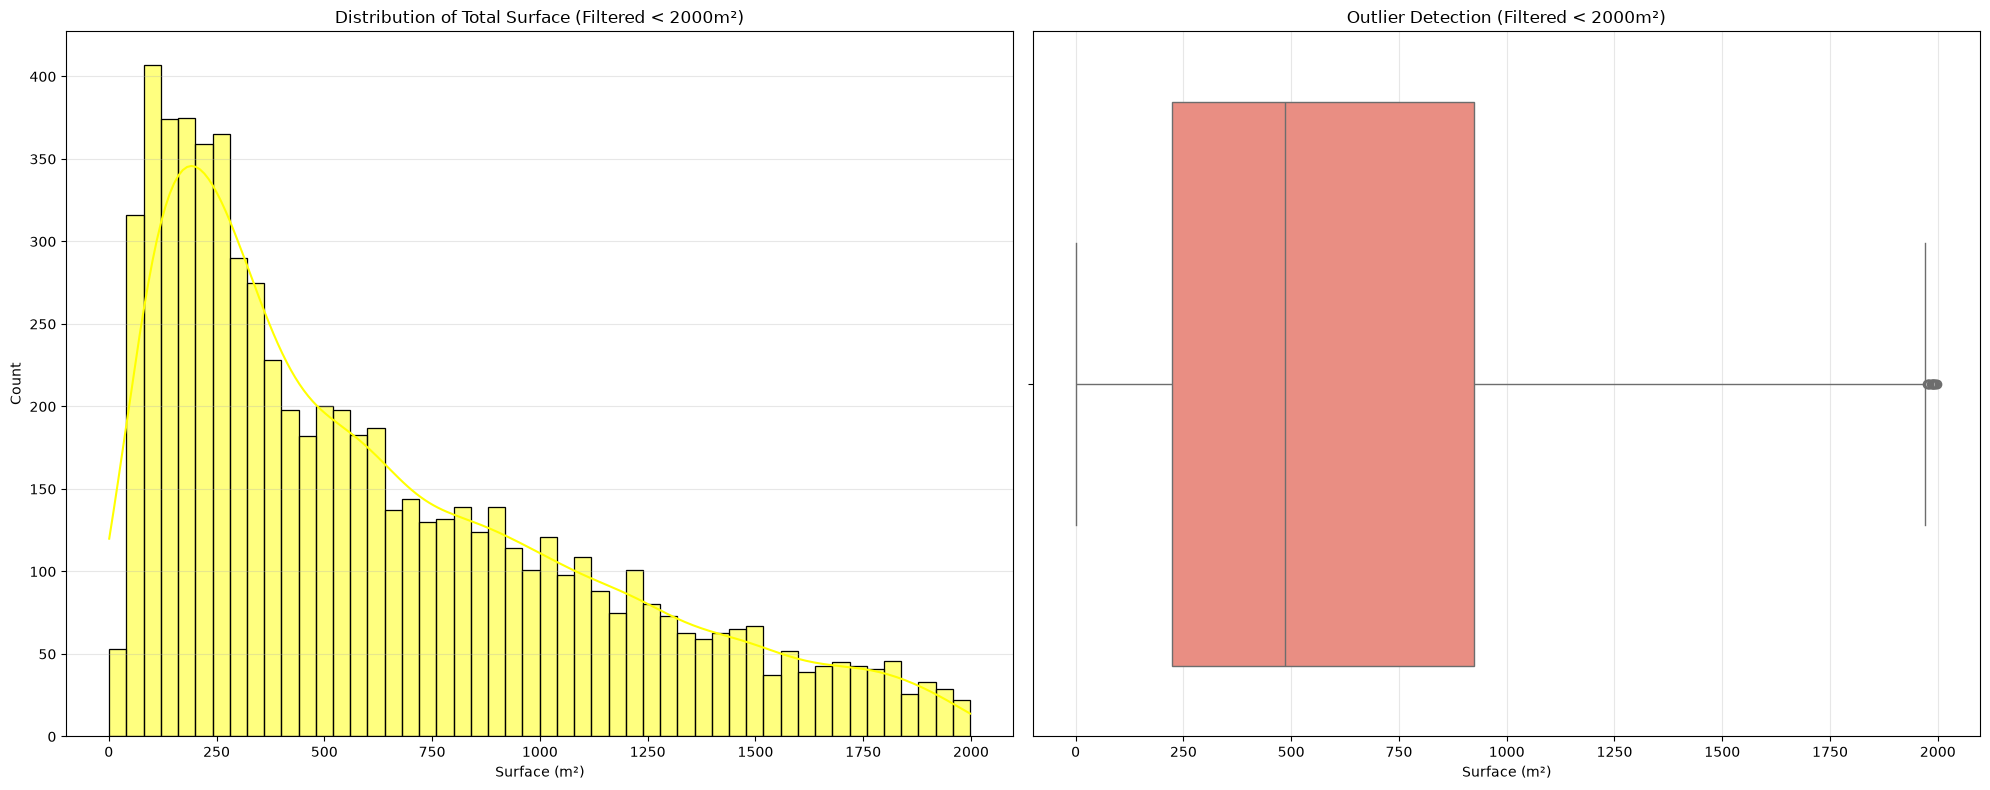

In [74]:
filtered_df = df[df['Total_surface'] < 2000]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(filtered_df['Total_surface'].dropna(), kde=True, ax=axes[0], color='yellow', bins=50)
axes[0].set_title('Distribution of Total Surface (Filtered < 2000m²)')
axes[0].set_xlabel('Surface (m²)')
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(x=filtered_df['Total_surface'].dropna(), ax=axes[1], color='salmon')
axes[1].set_title('Outlier Detection (Filtered < 2000m²)')
axes[1].set_xlabel('Surface (m²)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

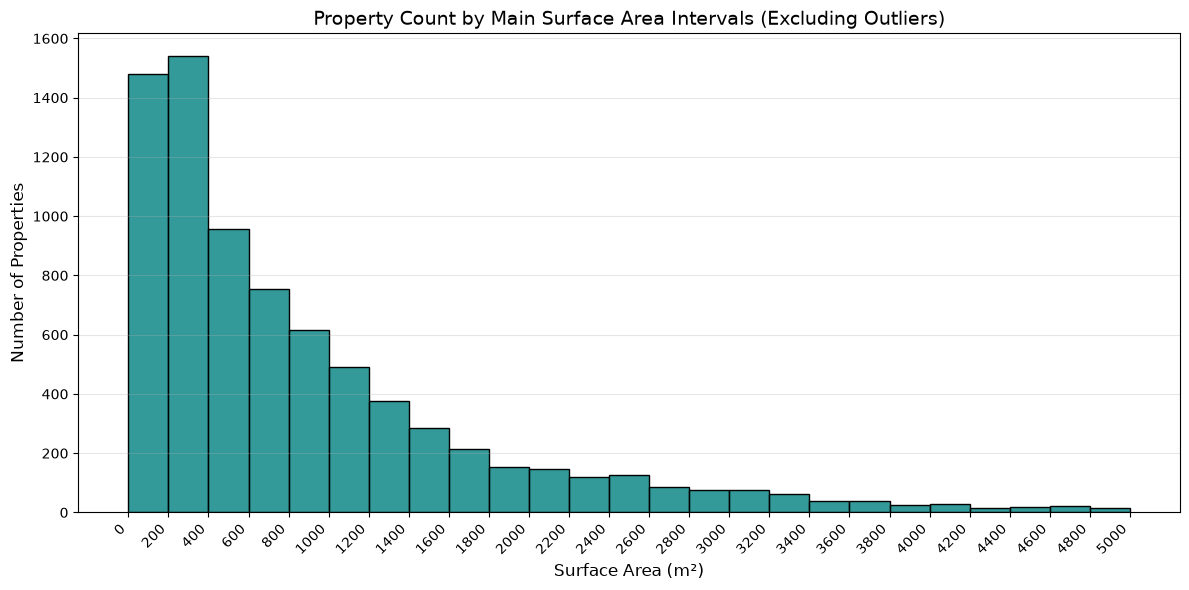

In [75]:
filtered_df = df[df['Total_surface'] < 5000].copy()

# Define the bins
bins = np.arange(0, 5001, 200)

# Setup the figure
plt.figure(figsize=(12, 6))

# Use 'Total_surface' here as well
sns.histplot(filtered_df['Total_surface'], bins=bins, color='teal', edgecolor='black', alpha=0.8)

# Set axis ticks
plt.xticks(ticks=bins, labels=[str(b) for b in bins], rotation=45, ha='right')

# Labels and Title
plt.title('Property Count by Main Surface Area Intervals (Excluding Outliers)', fontsize=14)
plt.xlabel('Surface Area (m²)', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Siegried\AppData\Local\Temp\ipykernel_5576\3066074502.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include=['object', 'category']).columns


--- Full Feature Importance Ranking ---
Livable_surface          0.44
Postcode                 0.12
Bedroom_count            0.08
Latitude                 0.05
Total_surface            0.04
Peb_category             0.04
Distance_nearest_city    0.03
Build_year               0.03
Garden_surface           0.03
Property_state           0.02
Longitude                0.02
Preschool_distance       0.02
City                     0.01
Train_station_distance   0.01
Supermarket_distance     0.01
Nearest_city             0.01
Swimming_pool            0.01
Province                 0.01
Property_type            0.00
Terrace                  0.00
Garage                   0.00
dtype: float64


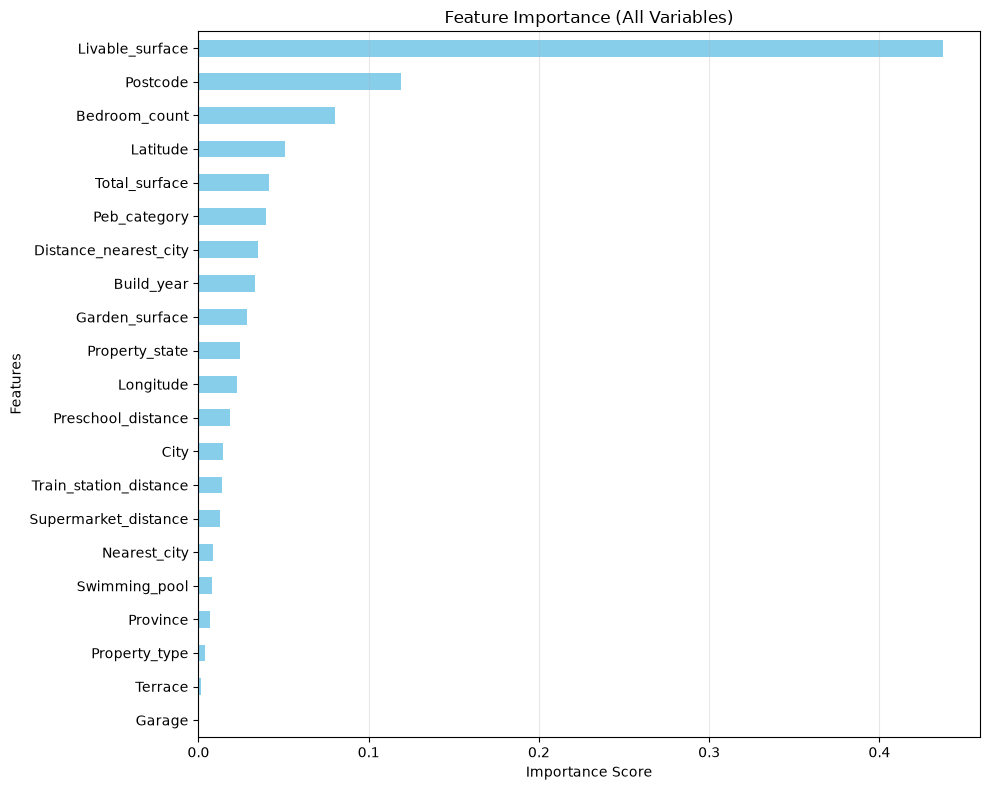

In [76]:
target = 'Price' 
# Exclude list matching file headers
features = [col for col in df.columns if col not in [target, 'Property_id', 'Address']]

# Prepare data subset
df_model = df[features + [target]].copy()

# Automated Preprocessing
numeric_cols = df_model.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(df_model[col].median())

encoders = {}
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df_model[col] = df_model[col].fillna("Unknown")
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

# Train the model
X = df_model[features]
y = df_model[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get and Display feature importances
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

print("--- Full Feature Importance Ranking ---")
print(importances.sort_values(ascending=False))

# Visualize
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance (All Variables)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

These numbers represent feature importance, showing how much each variable contributes to predicting the price. The values sum to 1.0 (100%).
Top Drivers: livable_surface (48%) and Price_m2 (35%) are our most influential features.
Minimal Impact: Features like terrace and garage (0.0%) contribute almost nothing to the model.
Key Insight: Since garage is at 0.0, it is likely mostly empty or irrelevant. We can safely remove it to simplify our model.

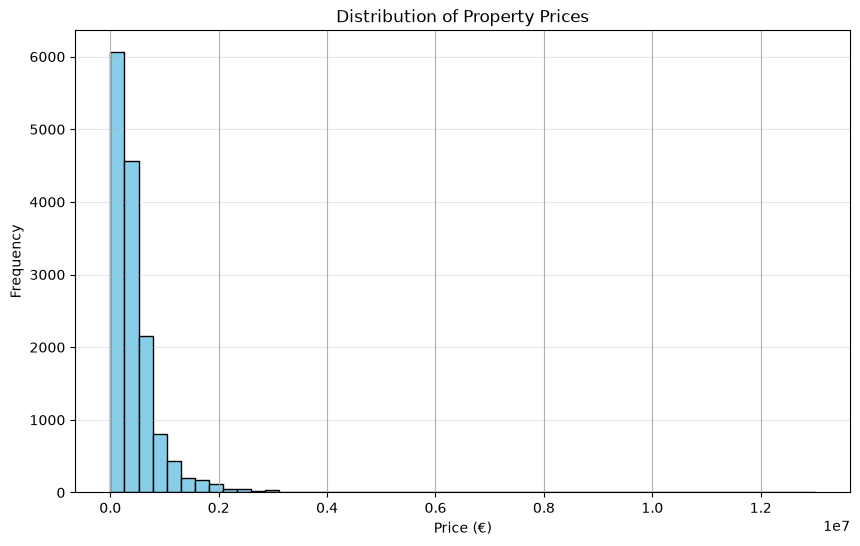

In [77]:
plt.figure(figsize=(10, 6))
df['Price'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (€)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\Siegried\AppData\Local\Temp\ipykernel_5576\787119353.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxplot = plt.boxplot(df['Price'].dropna(), vert=False, patch_artist=True,


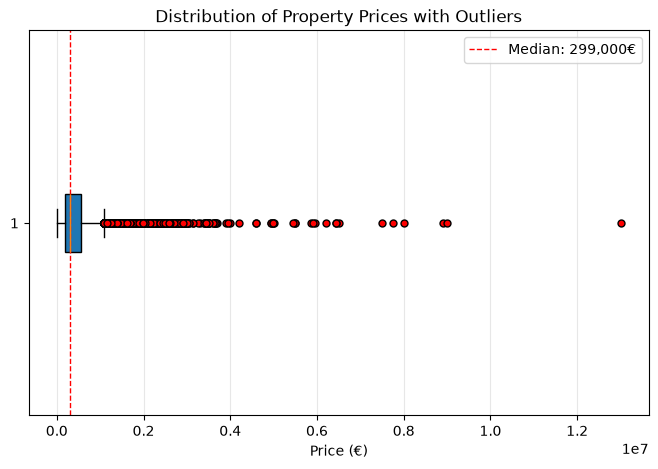

In [78]:
plt.figure(figsize=(8, 5))

boxplot = plt.boxplot(df['Price'].dropna(), vert=False, patch_artist=True, 
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

plt.title('Distribution of Property Prices with Outliers')
plt.xlabel('Price (€)')
plt.grid(axis='x', alpha=0.3)

median_val = df['Price'].median()
plt.axvline(median_val, color='red', linestyle='dashed', linewidth=1, label=f'Median: {median_val:,.0f}€')
plt.legend()

plt.show()

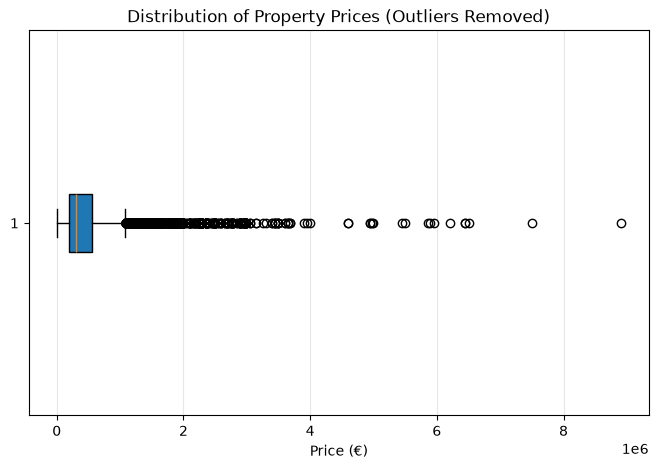

In [79]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_clean['Price'].dropna(), orientation='horizontal', patch_artist=True)

plt.title('Distribution of Property Prices (Outliers Removed)')
plt.xlabel('Price (€)')
plt.grid(axis='x', alpha=0.3)
plt.show()